## **Baselines Multimodales Intra-dominio**

El siguiente paso, una vez obtenidos los baselines unimodales y bimodales, es el entrenamiento, ajuste y validación de las arquitecturas multimodales por cada dominio individual, constituyendo la base de referencia en el posterior análisis comparativo de la fusión multidominio. 

### **Entrenamiento y Ajuste de Hiperparámetros**

Para la combinación de extractores seleccionada que mayor rendimiento conjunto obtienen, se entrenan a continuación las arquitecturas multimodales resultantes de combinar dichos extractores mediante las estrategias de **fusión temprana**, **fusión tardía mediante voto mayoritario**, **fusión tardía mediante promedio**, **fusión tardía mediante aproximación a regresión logística**, **fusión mediante atención** por cada dominio individual, llevando a cabo un ajuste de hiperparámetros.
- Recordamos la combinación de extractores ganadora seleccionada:

    1. **`ResNet` + `Wav2Vec` + `RoBERTa`**

La arquitectura multimodal cuenta con los siguientes componentes:

1. **Extractores seleccionados por cada modalidad** (ya indicados).
2. **Adaptadores** independientes por cada modalidad que mapeen dichos vectores de características extraídos a un espacio latente común normalizado (constituidos por una LSTM, en el caso de audio y vídeo, + capa lineal, además de aplicar normalización, ReLU y dropout). 
3. **Estrategia de Fusión**: Fusión Temprana / Fusión Tardía mediante voto mayoritario / Fusión Tardía mediante promedio / Fusión Tardía mediante aproximación a Regresión Logística / Fusión mediante Atención.
4. **Clasificador MLP**: En el caso de la **fusión temprana**, es el mismo clasificador explicado en el anterior notebook, constituido por las siguientes capas y en este mismo orden: `BatchNorm1d` (capa de normalización), `ReLU`, `Dropout`, capa lineal de compresión, `BatchNorm1d`, `ReLU`, `Dropout` y una última capa lineal para obtener el *logit* (resultado único en crudo de la red). Para el resto de fusiones se adapta adecuadamente (en el caso de las de fusión tardía, serán MLP individuales compuestos por 2 capas lineales que obtienen los logits por cada modalidad por separado, aplicando posteriormente la fusión a nivel de decisión; mientras que para la fusión mediante atención cuenta con una primera capa de atención, seguido del mismo clasificador MLP empleado para los baselines unimodales). 

Para llevar a cabo el ajuste de hiperparámetros, se ha optado por realizar dos Grid Search secuenciales: 

* **FASE 1: GRID SEARCH de ventanas de contexto**. Partiendo de la configuración básica para el resto de hiperparámetros (la predeterminada), vamos a realizar una primera búsqueda en rejilla para todas las combinaciones posibles de ventanas de contexto de las modalidades: 

    * **Vídeo**: `32 frames` vs `16 frames`.
    * **Audio**: `11 segundos` vs `7 segundos`.
    * **Texto**: `64 tokens` vs `32 tokens`.

De esta fase, fijamos la **combinación de ventanas de contexto** con las que mayor F1-Score Macro alcanza el modelo, superando el umbral de Recall de 0.45 para la clase de Estrés. Ante empate o valores muy ajustados en F1-Score Macro, se fija aquella configuración que obtenga el mayor **recall** para la clase positiva (Estrés).

* **FASE 2: GRID SEARCH para la capacidad de la arquitectura, regularización y aprendizaje**. Con las ventanas ya óptimas fijadas, se ajustará el tamaño de la red y su nivel de regularización mediante otro grid search:

    * **Red grande**: `proj_dim = 512` y `hidden_mlp = 128` vs **Red pequeña**:  `proj_dim = 256` y `hidden_mp = 64`.
    * **Dropout**: `0.5`(estándar) vs `0.3`(menor regularización, permite mayor flujo de información). 
    * **Learning Rate (`lr`)**: `1e-4` vs `5e-5` vs `1e-5`. Probamos con valores bajos ya que nuestro dataset es pequeño y desbalanceado, no conviene dar pasos grandes.


Los valores indicados para el ajuste por cada hiperparámetro se han extraído de la literatura (excepto las ventanas, extraídas del EDA). Se han limitado a una cantidad razonable para evitar la explosión combinatoria. 

Los modelos se entrenarán y ajustarán sobre:
- Particiones *train* y *dev* (para validación) del **Dataset Individual MELD (preprocesado)**.
- Particiones *train* y *dev* (para validación) del **Dataset Individual IEMOCAP (preprocesado)**.

Se obtendrá un modelo *ajustado* por cada uno de estos datasets y por cada estrategia de fusión. Se seleccionará, en el siguiente notebook, únicamente los modelos con aquellas técnicas de fusión que mayor rendimiento alcanzan en la partición de validación de su correspondiente dataset, resultando en **un baseline multimodal por dataset individual** que se enfrentará a test de su dataset.

In [1]:
# Importamos las librerías necesarias:

import os
import json
import matplotlib.pyplot as plt

------
## **Dataset MELD**

### **1. Fusión temprana**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"MELD_early_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:19<00:00, 16.16it/s, loss=1.42] 


Epoch 1. Train Loss: 1.1531. Val Loss: 1.1502. Val F1 Macro: 0.5743. Val Recall Estrés: 0.7150

Nuevo mejor modelo: (F1: 0.5743) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:19<00:00, 16.01it/s, loss=0.612]


Epoch 2. Train Loss: 1.0480. Val Loss: 1.0838. Val F1 Macro: 0.6380. Val Recall Estrés: 0.6995

Nuevo mejor modelo: (F1: 0.6380) -> Guardando pesos...


...

Epoch 9. Train Loss: 0.7580. Val Loss: 1.2081. Val F1 Macro: 0.6349. Val Recall Estrés: 0.6891

Sin mejora en F1-Score. Límite: 3/5


Epoch 10/20: 100%|██████████| 313/313 [00:16<00:00, 18.87it/s, loss=0.458]


Epoch 10. Train Loss: 0.7252. Val Loss: 1.2749. Val F1 Macro: 0.6275. Val Recall Estrés: 0.7098

Sin mejora en F1-Score. Límite: 4/5


Epoch 11/20: 100%|██████████| 313/313 [00:16<00:00, 18.85it/s, loss=0.32] 


Epoch 11. Train Loss: 0.6982. Val Loss: 1.7771. Val F1 Macro: 0.6463. Val Recall Estrés: 0.4456

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 11 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
MELD_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6506 | Recall estrés: 0.6580

CONFIGURACIÓN GANADORA: MELD_early_resnet16_wav2vec11s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6646


Las ventanas óptimas son:
* **Vídeo**: 16 frames.
* **Audio**: 11 segundos.
* **Texto**: 32 tokens.

Se observa que las ventanas de vídeo y texto han disminuido con respecto al modelo global. Esto puede indicar que en MELD el modelo no se ve beneficiado de ventanas de contexto grandes.

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"MELD_early_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 2/20:   1%|          | 2/313 [00:00<00:21, 14.67it/s, loss=1.31]

Epoch 1. Train Loss: 1.1625. Val Loss: 1.1655. Val F1 Macro: 0.6168. Val Recall Estrés: 0.6166

Nuevo mejor modelo: (F1: 0.6168) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:19<00:00, 16.11it/s, loss=1.95] 


Epoch 2. Train Loss: 1.0568. Val Loss: 1.0925. Val F1 Macro: 0.6296. Val Recall Estrés: 0.6943

Nuevo mejor modelo: (F1: 0.6296) -> Guardando pesos...


...

Epoch 12. Train Loss: 0.9495. Val Loss: 1.1110. Val F1 Macro: 0.5660. Val Recall Estrés: 0.8290

Sin mejora en F1-Score. Límite: 3/5


Epoch 13/20: 100%|██████████| 313/313 [00:18<00:00, 16.89it/s, loss=0.755]


Epoch 13. Train Loss: 0.9294. Val Loss: 1.1082. Val F1 Macro: 0.5618. Val Recall Estrés: 0.8238

Sin mejora en F1-Score. Límite: 4/5


Epoch 14/20: 100%|██████████| 313/313 [00:18<00:00, 16.80it/s, loss=0.696]


Epoch 14. Train Loss: 0.9075. Val Loss: 1.1016. Val F1 Macro: 0.5846. Val Recall Estrés: 0.7720

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 14 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_early_resnet16_wav2vec11s_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_early_resnet16_wav2vec11s_roberta32_p256_h64_lr1e-05_do0.3.json
MELD_early_resnet16_wav2vec11s_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.5907 | Recall estrés: 0.7461

CONFIGURACIÓN GANADORA: MELD_early_resnet16_wav2vec11s_roberta32_p256_h64_lr0.0001_do0.3
Mejor Val F1: 0.6739


La configuración óptima (F1=0.6739 | Recall=0.5285) para el modelo entrenado sobre MELD es:
* **VENTANAS**:
  * **Vídeo**: 16 frames
  * **Audio**: 11 segundos
  * **Texto**: 32 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
    * **Arquitectura**: `proj_dim` = 256, `hidden_mlp` = 64.
    * **Learning Rate**: `lr` = 1e-4 (valor predeterminado)
    * **Dropout**: `do` = 0.3


MEJOR CONFIGURACIÓN MELD FINAL: MELD_early_resnet16_wav2vec11s_roberta32_p256_h64_lr0.0001_do0.3
Mejor Val F1: 0.6739


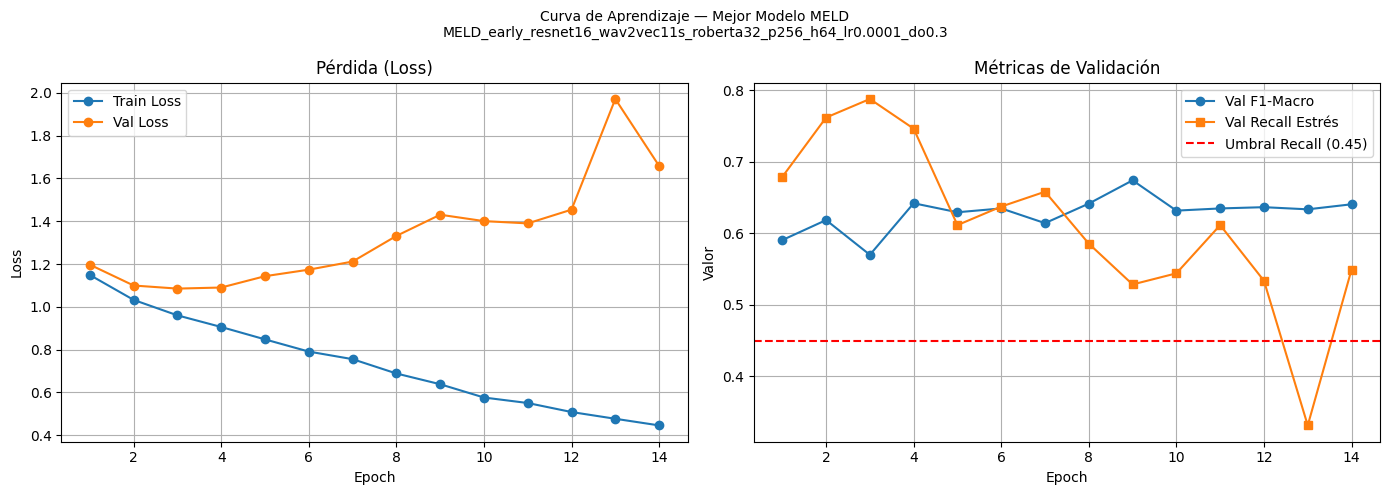

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN MELD FINAL: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")

    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo MELD\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'],label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_meld_early.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **2. Fusión Tardía mediante voto mayoritario**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"MELD_late_voto_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:21<00:00, 14.77it/s, loss=0.582]


Epoch 1. Train Loss: 1.1691. Val Loss: 1.1865. Val F1 Macro: 0.5383. Val Recall Estrés: 0.7927

Nuevo mejor modelo: (F1: 0.5383) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:18<00:00, 16.55it/s, loss=2.41] 


Epoch 2. Train Loss: 1.1190. Val Loss: 1.1864. Val F1 Macro: 0.4924. Val Recall Estrés: 0.8601

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 10. Train Loss: 0.9587. Val Loss: 1.2556. Val F1 Macro: 0.6133. Val Recall Estrés: 0.4974

Sin mejora en F1-Score. Límite: 3/5


Epoch 11/20: 100%|██████████| 313/313 [00:17<00:00, 17.99it/s, loss=0.586]


Epoch 11. Train Loss: 0.9201. Val Loss: 1.3309. Val F1 Macro: 0.5817. Val Recall Estrés: 0.3990

Sin mejora en F1-Score. Límite: 4/5


Epoch 12/20: 100%|██████████| 313/313 [00:17<00:00, 18.08it/s, loss=0.369]


Epoch 12. Train Loss: 0.9141. Val Loss: 1.2693. Val F1 Macro: 0.6088. Val Recall Estrés: 0.4870

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 12 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
MELD_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6488 | Recall estrés: 0.5285

CONFIGURACIÓN GANADORA: MELD_late_voto_resnet16_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6537


Las ventanas óptimas son:
* **Vídeo**: 16 frames
* **Audio**: 11 segundos
* **Texto**: 64 tokens

 * **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"MELD_late_voto_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:20<00:00, 14.96it/s, loss=0.584]


Epoch 1. Train Loss: 1.1835. Val Loss: 1.3060. Val F1 Macro: 0.6175. Val Recall Estrés: 0.3264

Nuevo mejor modelo: (F1: 0.6175) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:20<00:00, 15.36it/s, loss=0.569]


Epoch 2. Train Loss: 1.1367. Val Loss: 1.1939. Val F1 Macro: 0.5023. Val Recall Estrés: 0.8290

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 7. Train Loss: 1.1090. Val Loss: 1.2128. Val F1 Macro: 0.4730. Val Recall Estrés: 0.8394

Sin mejora en F1-Score. Límite: 3/5


Epoch 8/20: 100%|██████████| 313/313 [00:17<00:00, 17.88it/s, loss=2.36] 


Epoch 8. Train Loss: 1.0918. Val Loss: 1.2141. Val F1 Macro: 0.4955. Val Recall Estrés: 0.8031

Sin mejora en F1-Score. Límite: 4/5


Epoch 9/20: 100%|██████████| 313/313 [00:18<00:00, 16.82it/s, loss=2.06] 


Epoch 9. Train Loss: 1.0801. Val Loss: 1.2008. Val F1 Macro: 0.5130. Val Recall Estrés: 0.7979

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 9 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_late_voto_resnet16_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_late_voto_resnet16_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.json
MELD_late_voto_resnet16_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.5189 | Recall estrés: 0.8135

CONFIGURACIÓN GANADORA: MELD_late_voto_resnet16_wav2vec11s_roberta64_p512_h128_lr1e-05_do0.3
Mejor Val F1: 0.6442


El modelo con mayor rendimiento (F1=0.6442 | Recall=0.4663) tiene la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 16 frames
  * **Audio**: 11 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 1e-05
  * **Dropout**: `do` = 0.3


MEJOR CONFIGURACIÓN MELD LATE MEDIANTE VOTO: MELD_late_voto_resnet16_wav2vec11s_roberta64_p512_h128_lr1e-05_do0.3
Mejor Val F1: 0.6442


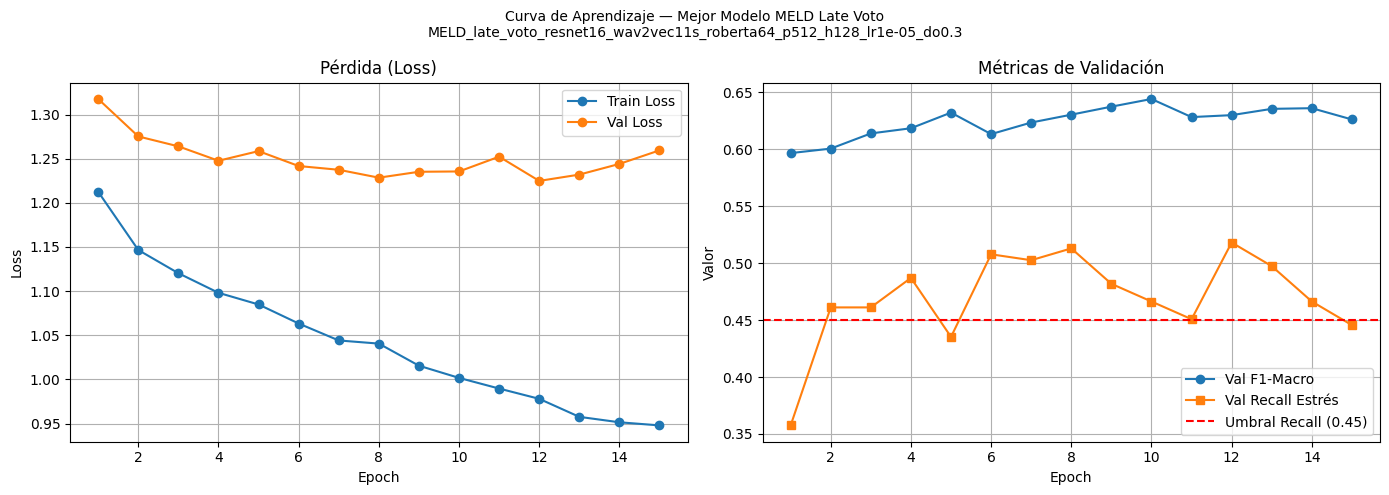

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN MELD LATE MEDIANTE VOTO: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo MELD Late Voto\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_MELD_late_voto.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **3. Fusión Tardía mediante promedio**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"MELD_late_promedio_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:27<00:00, 11.41it/s, loss=0.74] 


Epoch 1. Train Loss: 1.1103. Val Loss: 1.1453. Val F1 Macro: 0.6277. Val Recall Estrés: 0.6321

Nuevo mejor modelo: (F1: 0.6277) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:23<00:00, 13.54it/s, loss=1.88] 


Epoch 2. Train Loss: 1.0038. Val Loss: 1.1520. Val F1 Macro: 0.6496. Val Recall Estrés: 0.6166

Nuevo mejor modelo: (F1: 0.6496) -> Guardando pesos...


...

Epoch 10. Train Loss: 0.6490. Val Loss: 1.3610. Val F1 Macro: 0.6300. Val Recall Estrés: 0.5078

Sin mejora en F1-Score. Límite: 3/5


Epoch 11/20: 100%|██████████| 313/313 [00:16<00:00, 19.14it/s, loss=0.364]


Epoch 11. Train Loss: 0.6211. Val Loss: 1.3337. Val F1 Macro: 0.6381. Val Recall Estrés: 0.5492

Sin mejora en F1-Score. Límite: 4/5


Epoch 12/20: 100%|██████████| 313/313 [00:17<00:00, 18.32it/s, loss=0.744]


Epoch 12. Train Loss: 0.5922. Val Loss: 1.3640. Val F1 Macro: 0.6371. Val Recall Estrés: 0.5596

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 12 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
MELD_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6507 | Recall estrés: 0.6269

CONFIGURACIÓN GANADORA: MELD_late_promedio_resnet16_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6834


Ventanas óptimas:
* **Vídeo**: 16 frames
* **Audio**: 7 segundos
* **Texto**: 64 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"MELD_late_promedio_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:18<00:00, 16.59it/s, loss=0.672]


Epoch 1. Train Loss: 1.1078. Val Loss: 1.1268. Val F1 Macro: 0.5603. Val Recall Estrés: 0.7979

Nuevo mejor modelo: (F1: 0.5603) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:15<00:00, 20.27it/s, loss=0.583]


Epoch 2. Train Loss: 1.0074. Val Loss: 1.1023. Val F1 Macro: 0.6279. Val Recall Estrés: 0.6788

Nuevo mejor modelo: (F1: 0.6279) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.8002. Val Loss: 1.1401. Val F1 Macro: 0.6187. Val Recall Estrés: 0.6321

Sin mejora en F1-Score. Límite: 1/5


Epoch 19/20: 100%|██████████| 313/313 [00:14<00:00, 21.68it/s, loss=0.583]


Epoch 19. Train Loss: 0.7727. Val Loss: 1.1546. Val F1 Macro: 0.6286. Val Recall Estrés: 0.5907

Nuevo mejor modelo: (F1: 0.6286) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 313/313 [00:15<00:00, 20.62it/s, loss=0.779]


Epoch 20. Train Loss: 0.7501. Val Loss: 1.1476. Val F1 Macro: 0.6241. Val Recall Estrés: 0.6114

Sin mejora en F1-Score. Límite: 1/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_late_promedio_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_late_promedio_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.json
MELD_late_promedio_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6286 | Recall estrés: 0.5907

CONFIGURACIÓN GANADORA: MELD_late_promedio_resnet16_wav2vec7s_roberta64_p256_h64_lr0.0001_do0.3
Mejor Val F1: 0.6636


El modelo con mayor rendimiento (F1=0.6636 | Recall=0.5130) cuenta con la siguiente configuración:
* **Ventanas**:
  * **Vídeo**: 16 frames
  * **Audio**: 7 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 256, `hidden_mlp` = 64
  * **Learning Rate**: `lr` = 0.0001
  * **Dropout**: `do` = 0.3


MEJOR CONFIGURACIÓN MELD LATE MEDIANTE PROMEDIO: MELD_late_promedio_resnet16_wav2vec7s_roberta64_p256_h64_lr0.0001_do0.3
Mejor Val F1: 0.6636


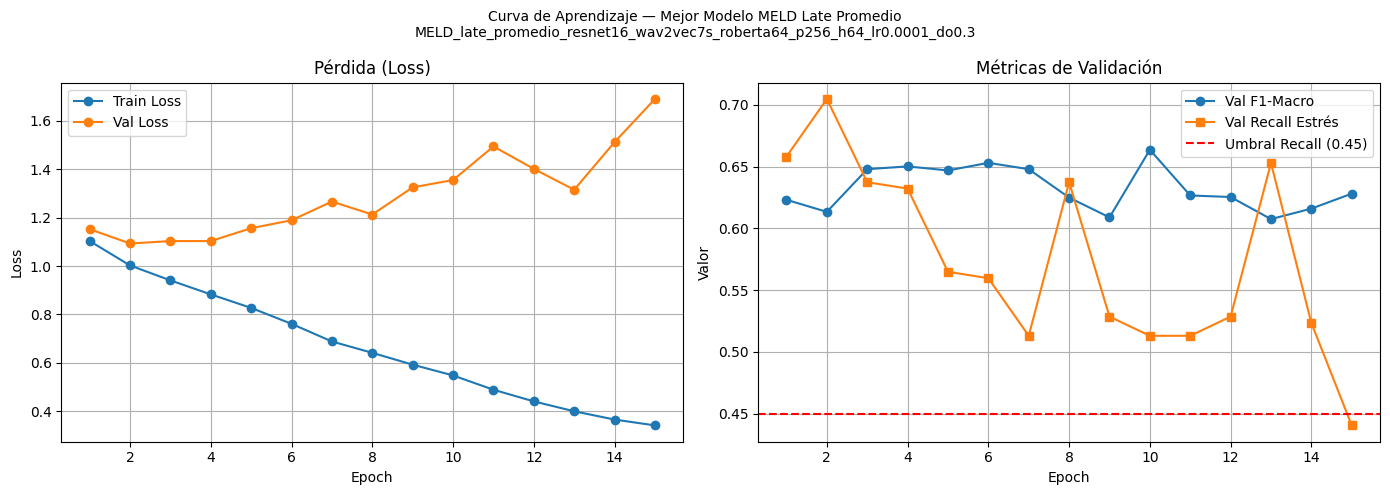

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN MELD LATE MEDIANTE PROMEDIO: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo MELD Late Promedio\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_MELD_late_promedio.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **4. Fusión Tardía mediante regresión logística**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"MELD_late_logistica_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:22<00:00, 13.98it/s, loss=0.885]


Epoch 1. Train Loss: 1.1154. Val Loss: 1.1778. Val F1 Macro: 0.5468. Val Recall Estrés: 0.7668

Nuevo mejor modelo: (F1: 0.5468) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:20<00:00, 15.00it/s, loss=2.95] 


Epoch 2. Train Loss: 1.0174. Val Loss: 1.1749. Val F1 Macro: 0.6082. Val Recall Estrés: 0.7098

Nuevo mejor modelo: (F1: 0.6082) -> Guardando pesos...


...

Epoch 5. Train Loss: 0.8727. Val Loss: 1.1010. Val F1 Macro: 0.6336. Val Recall Estrés: 0.7306

Sin mejora en F1-Score. Límite: 3/5


Epoch 6/20: 100%|██████████| 313/313 [00:15<00:00, 19.63it/s, loss=0.928]


Epoch 6. Train Loss: 0.8207. Val Loss: 1.1654. Val F1 Macro: 0.6552. Val Recall Estrés: 0.6166

Sin mejora en F1-Score. Límite: 4/5


Epoch 7/20: 100%|██████████| 313/313 [00:16<00:00, 19.25it/s, loss=0.511]


Epoch 7. Train Loss: 0.7527. Val Loss: 1.1229. Val F1 Macro: 0.6248. Val Recall Estrés: 0.6736

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 7 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
MELD_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6735 | Recall estrés: 0.5751

CONFIGURACIÓN GANADORA: MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6862


Las ventanas óptimas son:
* **Vídeo**: 32 frames
* **Audio**: 7 segundos
* **Texto**: 32 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"MELD_late_logistica_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:17<00:00, 17.68it/s, loss=0.603]


Epoch 1. Train Loss: 1.1027. Val Loss: 1.1189. Val F1 Macro: 0.6172. Val Recall Estrés: 0.6321

Nuevo mejor modelo: (F1: 0.6172) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:15<00:00, 20.19it/s, loss=3.2]  


Epoch 2. Train Loss: 1.0087. Val Loss: 1.0889. Val F1 Macro: 0.6528. Val Recall Estrés: 0.6166

Nuevo mejor modelo: (F1: 0.6528) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.8593. Val Loss: 1.0777. Val F1 Macro: 0.6457. Val Recall Estrés: 0.7617

Sin mejora en F1-Score. Límite: 3/5


Epoch 20/20:   1%|          | 3/313 [00:00<00:14, 21.62it/s, loss=0.674]

Epoch 19. Train Loss: 0.8431. Val Loss: 1.0791. Val F1 Macro: 0.6575. Val Recall Estrés: 0.7098

Nuevo mejor modelo: (F1: 0.6575) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 313/313 [00:13<00:00, 23.34it/s, loss=0.552]


Epoch 20. Train Loss: 0.8237. Val Loss: 1.0755. Val F1 Macro: 0.6342. Val Recall Estrés: 0.7565

Sin mejora en F1-Score. Límite: 1/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.json
MELD_late_logistica_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.6575 | Recall estrés: 0.7098

CONFIGURACIÓN GANADORA: MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6836


El modelo con mayor rendimiento (F1=0.6836 | Recall=0.5959) cuenta con la siguiente configuración:
* **Ventanas**:
  * **Vídeo**: 32 frames
  * **Audio**: 7 segundos
  * **Texto**: 32 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 0.0001
  * **Dropout**: `do` = 0.5


MEJOR CONFIGURACIÓN MELD LATE MEDIANTE REGRESIÓN LOGÍSTICA: MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6836


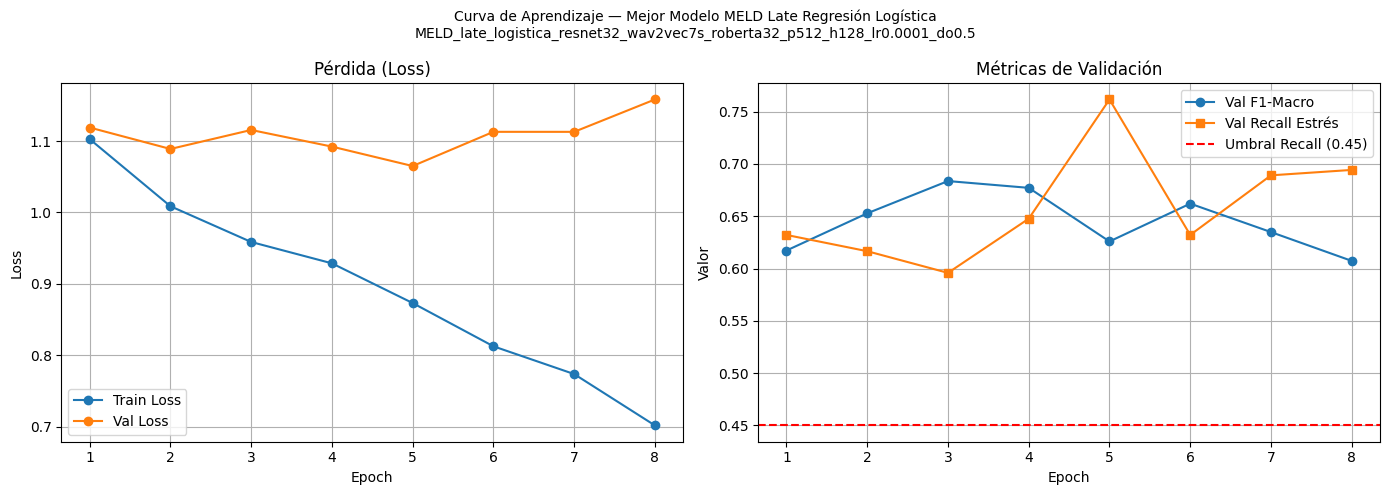

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN MELD LATE MEDIANTE REGRESIÓN LOGÍSTICA: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo MELD Late Regresión Logística\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_MELD_late_logistica.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **5. Fusión mediante atención**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"MELD_attention_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:22<00:00, 13.72it/s, loss=1.69] 


Epoch 1. Train Loss: 1.1025. Val Loss: 1.1124. Val F1 Macro: 0.6443. Val Recall Estrés: 0.6528

Nuevo mejor modelo: (F1: 0.6443) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:21<00:00, 14.37it/s, loss=0.515]


Epoch 2. Train Loss: 1.0045. Val Loss: 1.1158. Val F1 Macro: 0.6477. Val Recall Estrés: 0.6062

Nuevo mejor modelo: (F1: 0.6477) -> Guardando pesos...


...

Epoch 15. Train Loss: 0.5667. Val Loss: 1.4341. Val F1 Macro: 0.6444. Val Recall Estrés: 0.5648

Sin mejora en F1-Score. Límite: 3/5


Epoch 17/20:   1%|          | 3/313 [00:00<00:15, 20.24it/s, loss=0.477]

Epoch 16. Train Loss: 0.5586. Val Loss: 1.2505. Val F1 Macro: 0.6352. Val Recall Estrés: 0.6580

Sin mejora en F1-Score. Límite: 4/5


Epoch 17/20: 100%|██████████| 313/313 [00:14<00:00, 21.52it/s, loss=0.222]


Epoch 17. Train Loss: 0.5362. Val Loss: 1.4979. Val F1 Macro: 0.6421. Val Recall Estrés: 0.6010

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 17 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
MELD_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6595 | Recall estrés: 0.5440

CONFIGURACIÓN GANADORA: MELD_attention_resnet16_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.6821


Ventanas óptimas:
* **Vídeo**: 16 frames
* **Audio**: 7 segundos
* **Texto**: 64 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"MELD_attention_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset MELD "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 313/313 [00:17<00:00, 18.14it/s, loss=0.741]


Epoch 1. Train Loss: 1.1219. Val Loss: 1.1186. Val F1 Macro: 0.6218. Val Recall Estrés: 0.6684

Nuevo mejor modelo: (F1: 0.6218) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 313/313 [00:14<00:00, 21.14it/s, loss=0.672]


Epoch 2. Train Loss: 1.0064. Val Loss: 1.0766. Val F1 Macro: 0.6335. Val Recall Estrés: 0.7098

Nuevo mejor modelo: (F1: 0.6335) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.7257. Val Loss: 1.1252. Val F1 Macro: 0.6367. Val Recall Estrés: 0.6580

Nuevo mejor modelo: (F1: 0.6367) -> Guardando pesos...


Epoch 19/20: 100%|██████████| 313/313 [00:13<00:00, 22.64it/s, loss=2.16] 


Epoch 19. Train Loss: 0.7063. Val Loss: 1.1668. Val F1 Macro: 0.6372. Val Recall Estrés: 0.5959

Nuevo mejor modelo: (F1: 0.6372) -> Guardando pesos...


Epoch 20/20: 100%|██████████| 313/313 [00:15<00:00, 19.82it/s, loss=0.7]  


Epoch 20. Train Loss: 0.6717. Val Loss: 1.1432. Val F1 Macro: 0.6304. Val Recall Estrés: 0.6477

Sin mejora en F1-Score. Límite: 1/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_attention_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_attention_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.json
MELD_attention_resnet16_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6372 | Recall estrés: 0.5959

CONFIGURACIÓN GANADORA: MELD_attention_resnet16_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.6791


El mejor modelo (F1=0.6791 | Recall=0.6684) presenta la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 16 frames
  * **Audio**: 7 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 5e-05
  * **Dropout**: `do` = 0.3


MEJOR CONFIGURACIÓN MELD FINAL: MELD_attention_resnet16_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.6791


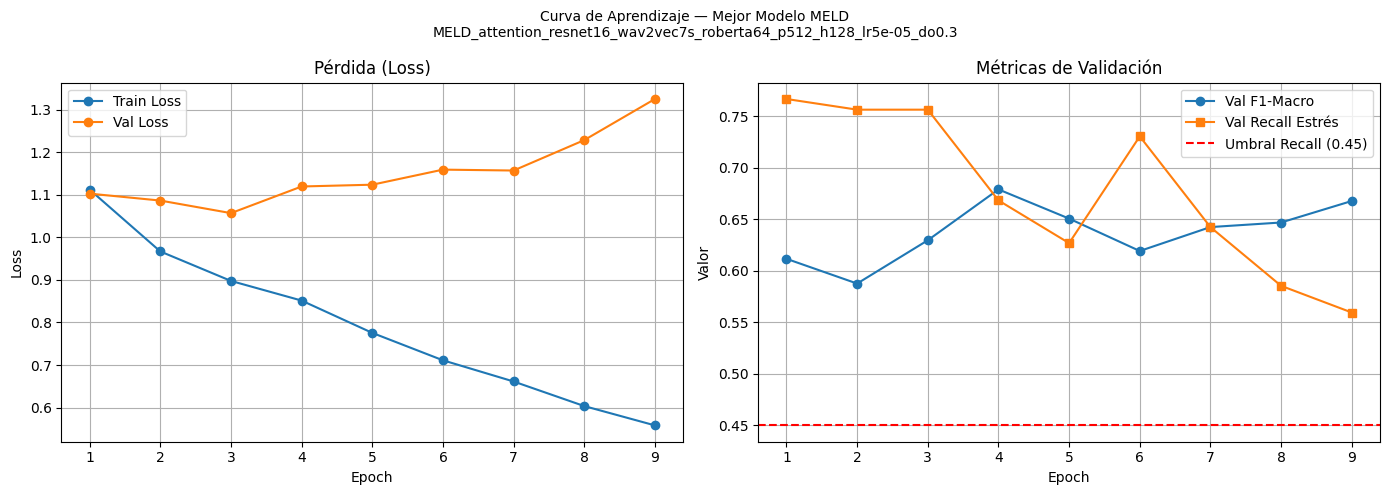

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN MELD FINAL: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")

    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo MELD\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'],label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_MELD_attention.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

-----
## **Dataset IEMOCAP**

### **1. Fusión Temprana**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"IEMOCAP_early_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:09<00:00, 14.14it/s, loss=0.758]


Epoch 1. Train Loss: 0.7579. Val Loss: 0.7144. Val F1 Macro: 0.5935. Val Recall Estrés: 0.5936

Nuevo mejor modelo: (F1: 0.5935) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:09<00:00, 14.50it/s, loss=0.869]


Epoch 2. Train Loss: 0.6736. Val Loss: 0.7109. Val F1 Macro: 0.5895. Val Recall Estrés: 0.6723

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 18. Train Loss: 0.2912. Val Loss: 0.8393. Val F1 Macro: 0.6633. Val Recall Estrés: 0.7426

Sin mejora en F1-Score. Límite: 1/5


Epoch 19/20: 100%|██████████| 141/141 [00:08<00:00, 17.61it/s, loss=0.27] 


Epoch 19. Train Loss: 0.2839. Val Loss: 1.1097. Val F1 Macro: 0.5773. Val Recall Estrés: 0.8574

Sin mejora en F1-Score. Límite: 2/5


Epoch 20/20: 100%|██████████| 141/141 [00:07<00:00, 18.36it/s, loss=0.674]


Epoch 20. Train Loss: 0.2777. Val Loss: 0.7147. Val F1 Macro: 0.6967. Val Recall Estrés: 0.7277

Sin mejora en F1-Score. Límite: 3/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
IEMOCAP_early_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7048 | Recall estrés: 0.5872

CONFIGURACIÓN GANADORA: IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7260


Las ventanas óptimas son:
* **Vídeo**: 32 frames
* **Audio**: 7 segundos
* **Texto**: 32 tokens

Para IEMOCAP, nos sorprende que el modelo reaccione con un comportamiento contrario al de MELD, donde aquí sí se beneficia de ventanas grandes de vídeo, reduciendo la ventana de audio. 

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"IEMOCAP_early_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion early "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: EARLY
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:09<00:00, 15.53it/s, loss=0.795]


Epoch 1. Train Loss: 0.7616. Val Loss: 0.7207. Val F1 Macro: 0.5927. Val Recall Estrés: 0.5979

Nuevo mejor modelo: (F1: 0.5927) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:08<00:00, 16.12it/s, loss=0.737]


Epoch 2. Train Loss: 0.6838. Val Loss: 0.7021. Val F1 Macro: 0.6086. Val Recall Estrés: 0.5511

Nuevo mejor modelo: (F1: 0.6086) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.4854. Val Loss: 0.7576. Val F1 Macro: 0.5510. Val Recall Estrés: 0.5000

Sin mejora en F1-Score. Límite: 1/5


Epoch 20/20:   2%|▏         | 3/141 [00:00<00:05, 23.37it/s, loss=0.42] 

Epoch 19. Train Loss: 0.4714. Val Loss: 0.7755. Val F1 Macro: 0.5525. Val Recall Estrés: 0.5277

Sin mejora en F1-Score. Límite: 2/5


Epoch 20/20: 100%|██████████| 141/141 [00:06<00:00, 23.01it/s, loss=0.39] 


Epoch 20. Train Loss: 0.4538. Val Loss: 0.7563. Val F1 Macro: 0.5665. Val Recall Estrés: 0.5489

Sin mejora en F1-Score. Límite: 3/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3.json
IEMOCAP_early_resnet32_wav2vec7s_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.5708 | Recall estrés: 0.6447

CONFIGURACIÓN GANADORA: IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7287


La configuración ganadora es (F1=0.7287 | Recall=0.6043):
* **Ventanas**:
  * **Vídeo**: 32 frames
  * **Audio**: 7 segundos
  * **Texto**: 32 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 1e-4 (valor predeterminado)
  * **Dropout**: `do` = 0.3


MEJOR CONFIGURACIÓN IEMOCAP FINAL: IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7287


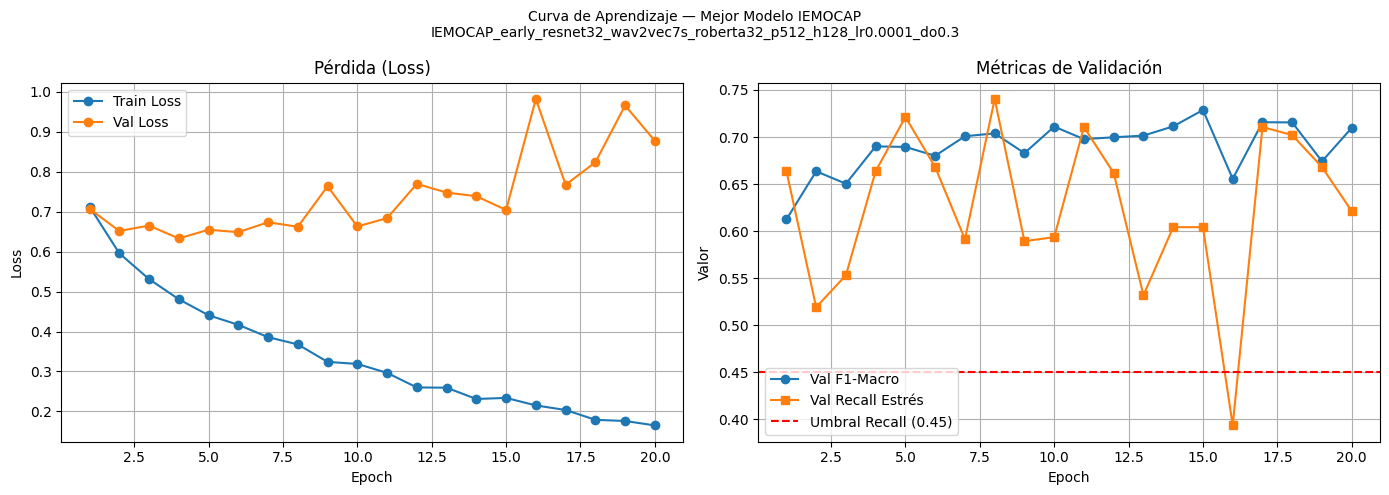

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN IEMOCAP FINAL: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")

    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo IEMOCAP\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'],label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_iemocap_early.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

Es en la epoch 15 donde el modelo alcanza su máximo rendimiento en F1-Score Macro en validación.

### **2. Fusión Tardía mediante voto mayoritario**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"IEMOCAP_late_voto_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:09<00:00, 14.37it/s, loss=0.697]


Epoch 1. Train Loss: 0.7613. Val Loss: 0.7022. Val F1 Macro: 0.6305. Val Recall Estrés: 0.4319

Nuevo mejor modelo: (F1: 0.6305) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:09<00:00, 14.93it/s, loss=0.678]


Epoch 2. Train Loss: 0.7045. Val Loss: 0.7331. Val F1 Macro: 0.5792. Val Recall Estrés: 0.8000

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 6. Train Loss: 0.6361. Val Loss: 0.7297. Val F1 Macro: 0.5928. Val Recall Estrés: 0.7809

Sin mejora en F1-Score. Límite: 3/5


Epoch 7/20: 100%|██████████| 141/141 [00:08<00:00, 17.18it/s, loss=0.769]


Epoch 7. Train Loss: 0.6272. Val Loss: 0.7338. Val F1 Macro: 0.5788. Val Recall Estrés: 0.8511

Sin mejora en F1-Score. Límite: 4/5


Epoch 8/20: 100%|██████████| 141/141 [00:08<00:00, 17.47it/s, loss=0.617]


Epoch 8. Train Loss: 0.6123. Val Loss: 0.7235. Val F1 Macro: 0.5940. Val Recall Estrés: 0.8383

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 8 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
IEMOCAP_late_voto_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.6532 | Recall estrés: 0.4468
--> DESCARTADO: Recall estrés (0.4468) < umbral (0.45)

CONFIGURACIÓN GANADORA: IEMOCAP_late_voto_resnet16_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7158


Las ventanas óptimas:
* **Vídeo**: 16 frames
* **Audio**: 11 segundos
* **Texto**: 64 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 16 
VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"IEMOCAP_late_voto_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion late "
                       f"--late_mode voto "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (16 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:12<00:00, 11.54it/s, loss=0.753]


Epoch 1. Train Loss: 0.7637. Val Loss: 0.7677. Val F1 Macro: 0.5386. Val Recall Estrés: 0.7255

Nuevo mejor modelo: (F1: 0.5386) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:09<00:00, 15.26it/s, loss=0.728]


Epoch 2. Train Loss: 0.7085. Val Loss: 0.7588. Val F1 Macro: 0.5459. Val Recall Estrés: 0.8170

Nuevo mejor modelo: (F1: 0.5459) -> Guardando pesos...


...

Epoch 14. Train Loss: 0.6516. Val Loss: 0.7034. Val F1 Macro: 0.6279. Val Recall Estrés: 0.4340

Sin mejora en F1-Score. Límite: 3/5


Epoch 15/20: 100%|██████████| 141/141 [00:09<00:00, 14.21it/s, loss=0.566]


Epoch 15. Train Loss: 0.6422. Val Loss: 0.7040. Val F1 Macro: 0.6199. Val Recall Estrés: 0.3872

Sin mejora en F1-Score. Límite: 4/5


Epoch 16/20: 100%|██████████| 141/141 [00:08<00:00, 17.19it/s, loss=0.576]


Epoch 16. Train Loss: 0.6468. Val Loss: 0.7021. Val F1 Macro: 0.6260. Val Recall Estrés: 0.4106

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 16 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_late_voto_resnet16_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_late_voto_resnet16_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.json
IEMOCAP_late_voto_resnet16_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6433 | Recall estrés: 0.4702

CONFIGURACIÓN GANADORA: IEMOCAP_late_voto_resnet16_wav2vec11s_roberta64_p512_h128_lr5e-05_do0.5
Mejor Val F1: 0.6875


El modelo que mayor rendimiento obtiene (F1=0.6875 | Recall=0.7447) presenta la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 16 frames
  * **Audio**: 11 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 5e-05
  * **Dropout**: `do` = 0.5

Observamos que el recall ha aumentado considerablemente con respecto a los modelos en MELD, algo esperable ya que en este dataset se presentan señales mucho más claras de estrés. Y, en este sentido, observamos que el modelo se ve beneficiado por ventanas de contexto mayores (en audio y texto), y presentando una arquitectura de red con mayor capacidad, ya que no pretende actuar de embudo ante el ruido, sino que ante las señales claras puede aprender relaciones más complejas y enriquecedoras para la tarea. 


MEJOR CONFIGURACIÓN IEMOCAP LATE MEDIANTE VOTO: IEMOCAP_late_voto_resnet16_wav2vec11s_roberta64_p512_h128_lr5e-05_do0.5
Mejor Val F1: 0.6875


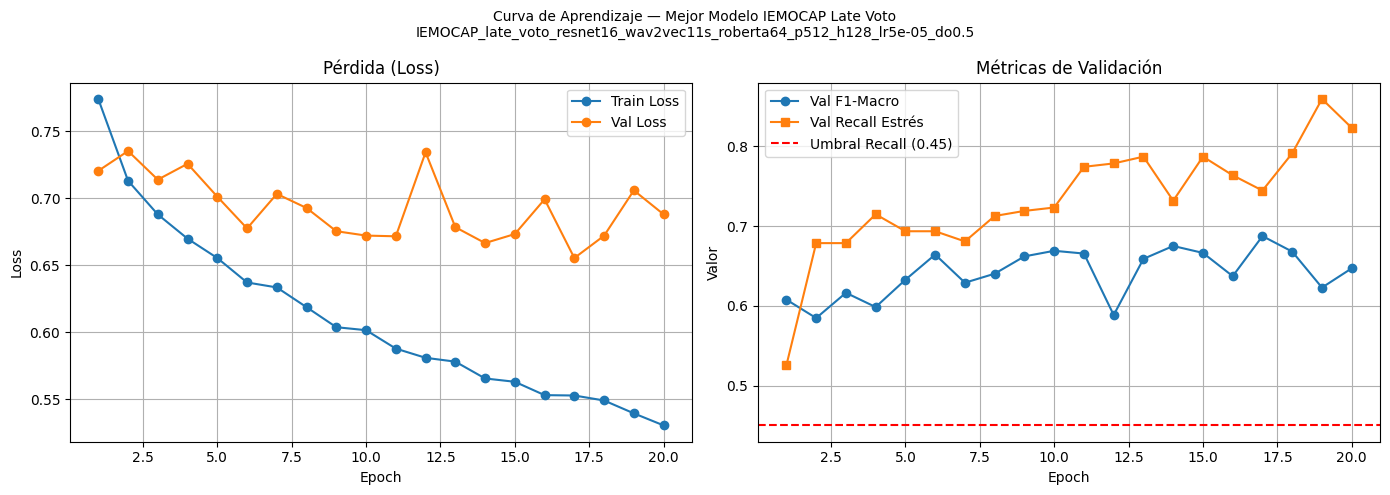

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN IEMOCAP LATE MEDIANTE VOTO: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo IEMOCAP Late Voto\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_IEMOCAP_late_voto.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **3. Fusión Tardía mediante promedio**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"IEMOCAP_late_promedio_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:08<00:00, 15.80it/s, loss=0.632]


Epoch 1. Train Loss: 0.7295. Val Loss: 0.7070. Val F1 Macro: 0.5970. Val Recall Estrés: 0.6191

Nuevo mejor modelo: (F1: 0.5970) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:09<00:00, 14.33it/s, loss=0.479]


Epoch 2. Train Loss: 0.6350. Val Loss: 0.6798. Val F1 Macro: 0.6308. Val Recall Estrés: 0.5787

Nuevo mejor modelo: (F1: 0.6308) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.2598. Val Loss: 0.7553. Val F1 Macro: 0.6470. Val Recall Estrés: 0.7128

Sin mejora en F1-Score. Límite: 2/5


Epoch 19/20: 100%|██████████| 141/141 [00:07<00:00, 18.05it/s, loss=0.18] 


Epoch 19. Train Loss: 0.2403. Val Loss: 0.7478. Val F1 Macro: 0.6699. Val Recall Estrés: 0.6213

Sin mejora en F1-Score. Límite: 3/5


Epoch 20/20: 100%|██████████| 141/141 [00:07<00:00, 18.05it/s, loss=0.22] 


Epoch 20. Train Loss: 0.2377. Val Loss: 0.6954. Val F1 Macro: 0.6827. Val Recall Estrés: 0.7681

Sin mejora en F1-Score. Límite: 4/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
IEMOCAP_late_promedio_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7153 | Recall estrés: 0.6043

CONFIGURACIÓN GANADORA: IEMOCAP_late_promedio_resnet32_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7273


Ventanas óptimas:
* **Vídeo**: 32 frames
* **Audio**: 11 segundos
* **Texto**: 64 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"IEMOCAP_late_promedio_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion late "
                       f"--late_mode promedio "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:08<00:00, 16.10it/s, loss=0.577]


Epoch 1. Train Loss: 0.7207. Val Loss: 0.7079. Val F1 Macro: 0.6083. Val Recall Estrés: 0.7021

Nuevo mejor modelo: (F1: 0.6083) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:09<00:00, 14.44it/s, loss=0.605]


Epoch 2. Train Loss: 0.6274. Val Loss: 0.6827. Val F1 Macro: 0.6112. Val Recall Estrés: 0.6957

Nuevo mejor modelo: (F1: 0.6112) -> Guardando pesos...


...

Epoch 16. Train Loss: 0.5312. Val Loss: 0.6990. Val F1 Macro: 0.6423. Val Recall Estrés: 0.7128

Sin mejora en F1-Score. Límite: 3/5


Epoch 17/20: 100%|██████████| 141/141 [00:10<00:00, 14.01it/s, loss=0.46] 


Epoch 17. Train Loss: 0.5183. Val Loss: 0.7079. Val F1 Macro: 0.6135. Val Recall Estrés: 0.7511

Sin mejora en F1-Score. Límite: 4/5


Epoch 18/20: 100%|██████████| 141/141 [00:08<00:00, 16.19it/s, loss=0.636]


Epoch 18. Train Loss: 0.5115. Val Loss: 0.7002. Val F1 Macro: 0.6312. Val Recall Estrés: 0.7149

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 18 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_late_promedio_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_late_promedio_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3.json
IEMOCAP_late_promedio_resnet32_wav2vec11s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.6678 | Recall estrés: 0.5830

CONFIGURACIÓN GANADORA: IEMOCAP_late_promedio_resnet32_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7183


El mejor modelo (F1=0.7183 | Recall=0.6255) presenta la siguiente configuración:
* **VENTANAS:**
  * **Vídeo**: 32 frames
  * **Audio**: 11 segundos
  * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 0.0001
  * **Dropout**: `do` = 0.3

En la misma línea al voto mayoritario, el modelo, para tomar la decisión mediante el promedio, vuelve a seleccionar ventanas de contexto mayores para las modalidades y arquitecturas con mayor capacidad, beneficiándose de las señales claras del dataset. 


MEJOR CONFIGURACIÓN IEMOCAP LATE MEDIANTE PROMEDIO: IEMOCAP_late_promedio_resnet32_wav2vec11s_roberta64_p512_h128_lr0.0001_do0.3
Mejor Val F1: 0.7183


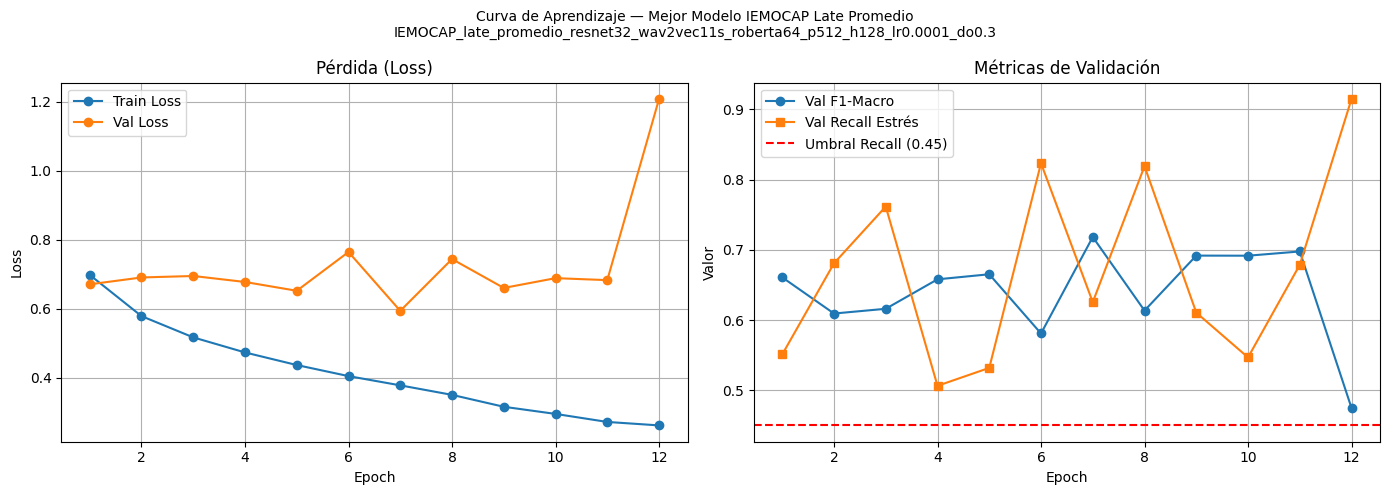

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN IEMOCAP LATE MEDIANTE PROMEDIO: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo IEMOCAP Late Promedio\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_IEMOCAP_late_promedio.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **4. Fusión Tardía mediante regresión logística**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"IEMOCAP_late_logistica_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:09<00:00, 14.64it/s, loss=0.679]


Epoch 1. Train Loss: 0.7240. Val Loss: 0.6998. Val F1 Macro: 0.5682. Val Recall Estrés: 0.3085

Nuevo mejor modelo: (F1: 0.5682) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:10<00:00, 14.02it/s, loss=0.703]


Epoch 2. Train Loss: 0.6338. Val Loss: 0.6802. Val F1 Macro: 0.6247. Val Recall Estrés: 0.5894

Nuevo mejor modelo: (F1: 0.6247) -> Guardando pesos...


...

Epoch 11. Train Loss: 0.3481. Val Loss: 0.6441. Val F1 Macro: 0.6909. Val Recall Estrés: 0.7021

Sin mejora en F1-Score. Límite: 3/5


Epoch 12/20: 100%|██████████| 141/141 [00:06<00:00, 20.37it/s, loss=0.346]


Epoch 12. Train Loss: 0.3239. Val Loss: 0.6496. Val F1 Macro: 0.6978. Val Recall Estrés: 0.6021

Sin mejora en F1-Score. Límite: 4/5


Epoch 13/20: 100%|██████████| 141/141 [00:07<00:00, 20.00it/s, loss=0.309]


Epoch 13. Train Loss: 0.3103. Val Loss: 0.6406. Val F1 Macro: 0.7009. Val Recall Estrés: 0.6894

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 13 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
IEMOCAP_late_logistica_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7081 | Recall estrés: 0.6383

CONFIGURACIÓN GANADORA: IEMOCAP_late_logistica_resnet32_wav2vec7s_roberta64_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7270


Las ventanas óptimas son:
* **Vídeo**: 32 frames
* **Audio**: 7 segundos
* **Texto**: 64 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 7
VENTANA_TEXTO = 'roberta64'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"IEMOCAP_late_logistica_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion late "
                       f"--late_mode logistica "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: LATE
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:09<00:00, 15.44it/s, loss=0.729]


Epoch 1. Train Loss: 0.7366. Val Loss: 0.7491. Val F1 Macro: 0.4970. Val Recall Estrés: 0.9021

Nuevo mejor modelo: (F1: 0.4970) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:09<00:00, 14.47it/s, loss=0.572]


Epoch 2. Train Loss: 0.6285. Val Loss: 0.7141. Val F1 Macro: 0.5683. Val Recall Estrés: 0.7872

Nuevo mejor modelo: (F1: 0.5683) -> Guardando pesos...


...

Epoch 18. Train Loss: 0.6094. Val Loss: 0.6386. Val F1 Macro: 0.7168. Val Recall Estrés: 0.7745

Nuevo mejor modelo: (F1: 0.7168) -> Guardando pesos...


Epoch 19/20: 100%|██████████| 141/141 [00:06<00:00, 20.87it/s, loss=0.538]


Epoch 19. Train Loss: 0.6034. Val Loss: 0.6463. Val F1 Macro: 0.6906. Val Recall Estrés: 0.8170

Sin mejora en F1-Score. Límite: 1/5


Epoch 20/20: 100%|██████████| 141/141 [00:06<00:00, 20.57it/s, loss=0.649]


Epoch 20. Train Loss: 0.5954. Val Loss: 0.6356. Val F1 Macro: 0.7044. Val Recall Estrés: 0.7894

Sin mejora en F1-Score. Límite: 2/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_late_logistica_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_late_logistica_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3.json
IEMOCAP_late_logistica_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3 --> F1: 0.7168 | Recall estrés: 0.7745
--> NUEVO MEJOR MODELO (F1=0.7168 | Recall=0.7745): IEMOCAP_late_logistica_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3

CONFIGURACIÓN GANADORA: IEMOCAP_late_logistica_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3
Mejor Val F1: 0.7168


El mejor modelo (F1=0.7168 | Recall=0.7745) contiene la siguiente configuración:
* **VENTANAS**:
    * **Vídeo**: 32 frames
    * **Audio**: 7 segundos
    * **Texto**: 64 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
    * **Arquitectura**: `proj_dim` = 256, `hidden_mlp` = 64
    * **Learning Rate**: `lr` = 1e-05
    * **Dropout**: `do` = 0.3

En las anteriores técnicas de fusión tardía, cada modalidad emite un voto o logit final para la decisión final, mientras que en esta aproximación a la regresión logística, tenemos una capa final adicional que es la que aprende a ponderar cada una de estas modalidades para tomar la decisión, y la reducción de la ventana de audio en este sentido nos indica el modelo prefiere extraer características acústicas muy localizadas. Además, la arquitectura de la red es de una menor capacidad.



MEJOR CONFIGURACIÓN IEMOCAP LATE MEDIANTE REGRESIÓN LOGÍSTICA: IEMOCAP_late_logistica_resnet32_wav2vec7s_roberta64_p256_h64_lr1e-05_do0.3
Mejor Val F1: 0.7168


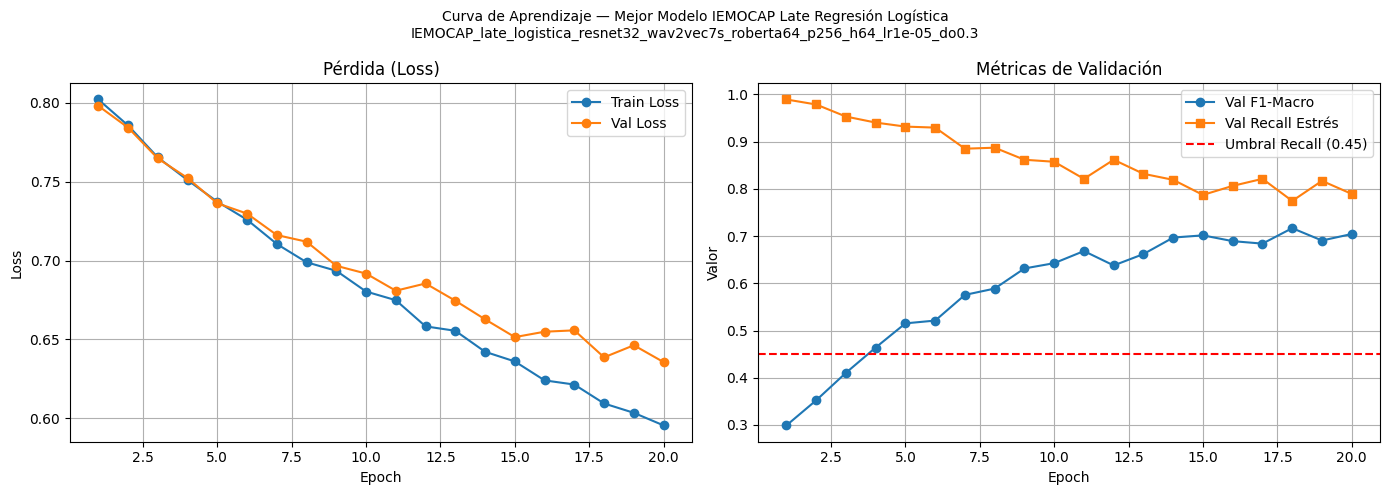

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN IEMOCAP LATE MEDIANTE REGRESIÓN LOGÍSTICA: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")
    
    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo IEMOCAP Late Regresión Logística\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'],label='Val Loss',   marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'], label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_IEMOCAP_late_logistica.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")

### **5. Fusión mediante Atención**

* **FASE 1: GRID SEARCH de Ventanas de contexto**

In [ ]:
#-------------------------- Ventanas a ajustar ------------------------

VENTANAS_VIDEO = [32, 16]
VENTANAS_AUDIO = [11, 7]
VENTANAS_TEXTO = ['roberta64', 'roberta32']

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec'
lr = 1e-4
do = 0.5
h_mlp = 128
prj_dim = 512

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for video_frames in VENTANAS_VIDEO:
    for audio_len in VENTANAS_AUDIO:
        for text_model in VENTANAS_TEXTO:

            nombre_base = (f"IEMOCAP_attention_{VIDEO_BACKBONE}{video_frames}_{AUDIO_BACKBONE}{audio_len}s_{text_model}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {video_frames} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {audio_len} "
                       f"--text {text_model} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta64 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 141/141 [00:11<00:00, 12.52it/s, loss=0.611]


Epoch 1. Train Loss: 0.7249. Val Loss: 0.6731. Val F1 Macro: 0.6301. Val Recall Estrés: 0.4723

Nuevo mejor modelo: (F1: 0.6301) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:09<00:00, 15.12it/s, loss=0.503]


Epoch 2. Train Loss: 0.6299. Val Loss: 0.6813. Val F1 Macro: 0.6197. Val Recall Estrés: 0.6447

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 11. Train Loss: 0.3698. Val Loss: 0.6612. Val F1 Macro: 0.6858. Val Recall Estrés: 0.7170

Sin mejora en F1-Score. Límite: 3/5


Epoch 12/20: 100%|██████████| 141/141 [00:07<00:00, 17.86it/s, loss=0.819]


Epoch 12. Train Loss: 0.3629. Val Loss: 0.7194. Val F1 Macro: 0.6601. Val Recall Estrés: 0.8213

Sin mejora en F1-Score. Límite: 4/5


Epoch 13/20: 100%|██████████| 141/141 [00:08<00:00, 16.56it/s, loss=0.372]


Epoch 13. Train Loss: 0.3385. Val Loss: 0.6918. Val F1 Macro: 0.6835. Val Recall Estrés: 0.7213

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 13 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.json
IEMOCAP_attention_resnet16_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5 --> F1: 0.7063 | Recall estrés: 0.5149

CONFIGURACIÓN GANADORA: IEMOCAP_attention_resnet32_wav2vec11s_roberta32_p512_h128_lr0.0001_do0.5
Mejor Val F1: 0.7337


Ventanas óptimas:
* **Vídeo**: 32 frames
* **Audio**: 11 segundos
* **Texto**: 32 tokens

* **FASE 2: GRID SEARCH para la Capacidad de la Arquitectura, Regularización y Aprendizaje**

In [ ]:
#-------------------------- Hiperparámetros a ajustar ------------------------

confg_arq = [(512,128), (256,64)]
LRS = [1e-4,5e-5,1e-5]
dropouts = [0.5, 0.3]

# ------------------------ Valores ya ajustados ------------------------

VENTANA_VIDEO = 32
VENTANA_AUDIO = 11
VENTANA_TEXTO = 'roberta32'

# ----------------------- Configuración básica --------------------------

VIDEO_BACKBONE = 'resnet'
AUDIO_BACKBONE = 'wav2vec' 

RECALL_ESTRES_MINIMO = 0.45  # Filtro mínimo obligatorio para la clase estrés, si el modelo no alcanza este recall en estrés se descarta

mejor_f1 = 0.0
mejor_config = None

for prj_dim, h_mlp in confg_arq:
    for lr in LRS:
        for do in dropouts:

            nombre_base = (f"IEMOCAP_attention_{VIDEO_BACKBONE}{VENTANA_VIDEO}_{AUDIO_BACKBONE}{VENTANA_AUDIO}s_{VENTANA_TEXTO}_p{prj_dim}_h{h_mlp}_lr{lr}_do{do}")
            pth_path = f"pesos_modelo_estres_{nombre_base}.pth"
            json_path = f"historial_estres_{nombre_base}.json"

            comando = (f"python train.py "
                       f"--train_dataset IEMOCAP "
                       f"--fusion attention "
                       f"--video {VIDEO_BACKBONE} "
                       f"--video_frames {VENTANA_VIDEO} "
                       f"--audio {AUDIO_BACKBONE} "
                       f"--audio_len {VENTANA_AUDIO} "
                       f"--text {VENTANA_TEXTO} "
                       f"--proj_dim {prj_dim} "
                       f"--hidden_mlp {h_mlp} "
                       f"--lr {lr} "
                       f"--dropout {do} ")
                        
            os.system(comando)

            # Extraemos ambas métricas del historial:
            val_f1 = 0.0
            val_recall = 0.0
            
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    historial = json.load(f)
                
                # Buscamos el índice de la época con el mejor F1
                mejores_f1_lista = historial['val_f1']
                if mejores_f1_lista:
                    mejor_indice = mejores_f1_lista.index(max(mejores_f1_lista))
                    
                    val_f1 = historial['val_f1'][mejor_indice]
                    val_recall = historial['val_recall_estres'][mejor_indice]

            print(f"{nombre_base} --> F1: {val_f1:.4f} | Recall estrés: {val_recall:.4f}")

            # Doble criterio: filtro de recall + selección por F1-Macro
            supera_filtro = val_recall >= RECALL_ESTRES_MINIMO
            mejora_f1 = val_f1 > mejor_f1

            if supera_filtro and mejora_f1:
                # ACTUALIZAMOS EL MEJOR MODELO (eliminando el antiguo mejor modelo)
                if mejor_config is not None:
                    for archivo in [f"pesos_modelo_estres_{mejor_config}.pth", f"historial_estres_{mejor_config}.json"]:
                        if os.path.exists(archivo):
                            os.remove(archivo)

                mejor_f1 = val_f1
                mejor_config = nombre_base
                print(f"--> NUEVO MEJOR MODELO (F1={mejor_f1:.4f} | Recall={val_recall:.4f}): {nombre_base}")
            else :
                if not supera_filtro:
                    print(f"--> DESCARTADO: Recall estrés ({val_recall:.4f}) < umbral ({RECALL_ESTRES_MINIMO})")
                for archivo in [pth_path, json_path]:
                    if os.path.exists(archivo):
                        os.remove(archivo)

# Mostramos la configuración ganadora:
print(f"\nCONFIGURACIÓN GANADORA: {mejor_config}")
print(f"Mejor Val F1: {mejor_f1:.4f}")

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (11s -> 550 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 2/20:   1%|▏         | 2/141 [00:00<00:08, 16.52it/s, loss=0.689]

Epoch 1. Train Loss: 0.7476. Val Loss: 0.7082. Val F1 Macro: 0.5916. Val Recall Estrés: 0.6830

Nuevo mejor modelo: (F1: 0.5916) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 141/141 [00:08<00:00, 16.31it/s, loss=0.512]


Epoch 2. Train Loss: 0.6312. Val Loss: 0.7261. Val F1 Macro: 0.5800. Val Recall Estrés: 0.7362

Sin mejora en F1-Score. Límite: 1/5


...

Epoch 18. Train Loss: 0.4605. Val Loss: 0.7408. Val F1 Macro: 0.5733. Val Recall Estrés: 0.6213

Sin mejora en F1-Score. Límite: 2/5


Epoch 19/20: 100%|██████████| 141/141 [00:09<00:00, 15.52it/s, loss=0.453]


Epoch 19. Train Loss: 0.4477. Val Loss: 0.7301. Val F1 Macro: 0.5862. Val Recall Estrés: 0.5255

Sin mejora en F1-Score. Límite: 3/5


Epoch 20/20: 100%|██████████| 141/141 [00:08<00:00, 16.22it/s, loss=0.654]


Epoch 20. Train Loss: 0.4434. Val Loss: 0.7499. Val F1 Macro: 0.5648. Val Recall Estrés: 0.6511

Sin mejora en F1-Score. Límite: 4/5
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_attention_resnet32_wav2vec11s_roberta32_p256_h64_lr1e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_attention_resnet32_wav2vec11s_roberta32_p256_h64_lr1e-05_do0.3.json
IEMOCAP_attention_resnet32_wav2vec11s_roberta32_p256_h64_lr1e-05_do0.3 --> F1: 0.5942 | Recall estrés: 0.5596

CONFIGURACIÓN GANADORA: IEMOCAP_attention_resnet32_wav2vec11s_roberta32_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7264


El modelo con mayor rendimiento (F1=0.7264 | Recall=0.6511) presenta la siguiente configuración:
* **VENTANAS**:
  * **Vídeo**: 32 frames
  * **Audio**: 11 segundos
  * **Texto**: 32 tokens
* **Capacidad de la Arquitectura, Regularización y Aprendizaje**:
  * **Arquitectura**: `proj_dim` = 512, `hidden_mlp` = 128
  * **Learning Rate**: `lr` = 5e-05
  * **Dropout**: `do` = 0.3

Este modelo es el único, para la técnica de fusión mediante atención, que se beneficia de una mayor ventana de contexto en audio. Es el texto la única que se reduce. Además, cuenta con una capacidad mayor, como el resto de modelos para esta técnica. 


MEJOR CONFIGURACIÓN IEMOCAP FINAL: IEMOCAP_attention_resnet32_wav2vec11s_roberta32_p512_h128_lr5e-05_do0.3
Mejor Val F1: 0.7264


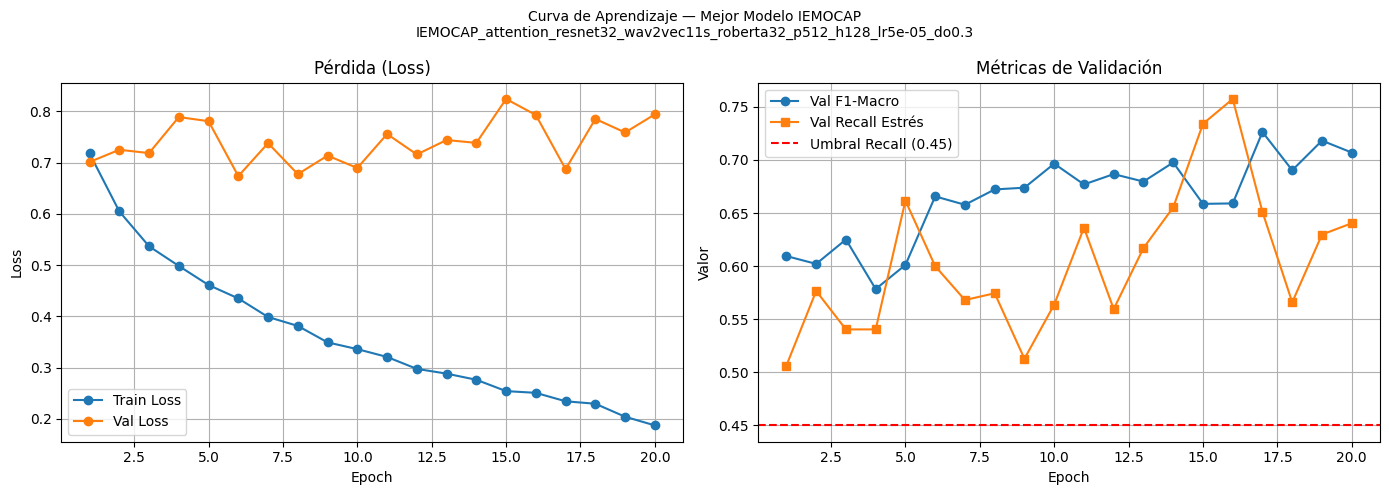

In [ ]:
# ----------- MOSTRAMOS LOS RESULTADOS Y LA CURVA DE APRENDIZAJE DEL MEJOR MODELO -----------

if mejor_config is not None:

    print(f"\nMEJOR CONFIGURACIÓN IEMOCAP FINAL: {mejor_config}")
    print(f"Mejor Val F1: {mejor_f1:.4f}")

    json_mejor = f"historial_estres_{mejor_config}.json"
    with open(json_mejor, 'r') as f:
        historial_mejor = json.load(f)

    epochs_range = range(1, len(historial_mejor['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Curva de Aprendizaje — Mejor Modelo IEMOCAP\n{mejor_config}", fontsize=10)

    # --- Subplot 1: Train Loss vs Val Loss ---
    axes[0].plot(epochs_range, historial_mejor['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(epochs_range, historial_mejor['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # --- Subplot 2: Val F1-Macro vs Val Recall Estrés ---
    axes[1].plot(epochs_range, historial_mejor['val_f1'], label='Val F1-Macro', marker='o')
    axes[1].plot(epochs_range, historial_mejor['val_recall_estres'],label='Val Recall Estrés', marker='s')
    axes[1].axhline(y=RECALL_ESTRES_MINIMO, color='red', linestyle='--', label=f'Umbral Recall ({RECALL_ESTRES_MINIMO})')
    axes[1].set_title('Métricas de Validación')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Valor')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"Fig_curva_aprendizaje_mejor_modelo_IEMOCAP_attention.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No se encontró ningún modelo que superara el filtro de Recall mínimo.")